In [ ]:
from sympy import *
from IPython.display import display
init_printing()

x, t = symbols('x t')
lam = symbols('lambda')

v = Function('v')(x, t)

a = Function('a')(x, t)
b = Function('b')(x, t)
c = Function('c')(x, t)
d = Function('d')(x, t)

H = Matrix([
    [1,0],
    [0,-1]
])

Ep = Matrix([
    [0,1],
    [0,0]
])

Em = Matrix([
    [0,0],
    [1,0]
])

E = Ep + lam*Em

A0 = v*H

At = (
    lam*E
    + a*lam*H
    + b*Ep
    + c*lam*Em
    + d*H
)

def comm(A,B):
    return expand(A*B - B*A)

zc = expand(
    -diff(A0,t)
    + diff(At,x)
    + comm(E,At)
    + comm(A0,At)
)

eq_H  = expand(zc[0,0])
eq_Ep = expand(zc[0,1])
eq_Em = expand(zc[1,0])


def split_lambda(expr):

    expr = expand(expr)

    poly = Poly(expr, lam)

    out = {}

    for power, coeff in poly.terms():

        p = power[0]

        out[p] = expand(coeff)

    return out

H_split = split_lambda(eq_H)

Ep_split = split_lambda(eq_Ep)

Em_split = split_lambda(eq_Em)

eq_a = simplify(Ep_split[1]/2)

sol_a = solve(eq_a, a)[0]

eq_bc = H_split[1].subs(a, sol_a)

rel1 = solve(eq_bc, c)[0]

eq_d1 = simplify(Ep_split[0]/2)

eq_d1 = eq_d1.subs(a, sol_a)

sol_d1 = solve(eq_d1, d)[0]

eq_d2 = simplify(Em_split[1]/2)

eq_d2 = eq_d2.subs(a, sol_a)


eq_d2 = expand(eq_d2.subs(d, sol_d1))

eq_d2 = expand(eq_d2.subs(c, rel1))

eq_d2 = simplify(eq_d2)

bx = diff(b,x)

candidate_b = (
    diff(v,x) - v**2
)/2

candidate_c = expand(rel1.subs(b, candidate_b))

candidate_d = expand(sol_d1.subs(b, candidate_b))

candidate_d = simplify(candidate_d)

final_flow = expand(
    H_split[0]
    .subs(d, candidate_d)
)

expanded = expand(final_flow.doit())
overall = factor_terms(expanded)
display(overall)
vt_expr = solve(
    expanded,
    diff(v,t)
)[0]

display(Eq(diff(v,t), vt_expr))

vx    = Symbol("v_x")
vxx   = Symbol("v_xx")
vxxx  = Symbol("v_xxx")
vt    = Symbol("v_t")

pretty = (
    vt_expr
    .xreplace({
        diff(v,x,3): Symbol("v_xxx"),
        diff(v,x,2): Symbol("v_xx"),
        diff(v,x):   Symbol("v_x"),
        diff(v,t):   Symbol("v_t"),
        v:           Symbol("v")
    })
)
overall = factor_terms(pretty)

display(Eq(vt, (overall)))

vt = solve(final_flow, diff(v,t))[0]

vt = simplify(expand(vt))

# display(vt)

                                          3          
                                         ∂           
     2       ∂                           ───(v(x, t))
  3⋅v (x, t)⋅──(v(x, t))                   3         
             ∂x            ∂             ∂x          
- ────────────────────── - ──(v(x, t)) + ────────────
            2              ∂t                 4      

                                          3          
                                         ∂           
                   2       ∂             ───(v(x, t))
                3⋅v (x, t)⋅──(v(x, t))     3         
∂                          ∂x            ∂x          
──(v(x, t)) = - ────────────────────── + ────────────
∂t                        2                   4      

          2          
     - 6⋅v ⋅vₓ + vₓₓₓ
vₜ = ────────────────
            4        

In [1]:
from sympy import *
from IPython.display import display
init_printing()

x, t = symbols('x t')
lam = symbols('lambda')

v = Function('v')(x, t)

a = Function('a')(x, t)
b = Function('b')(x, t)
c1 = Function('c1')(x, t)
c2 = Function('c2')(x, t)
d = Function('d')(x, t)

a = 1

H = Matrix([
    [1,0],
    [0,-1]
])

Ep = Matrix([
    [0,1],
    [0,0]
])

Em = Matrix([
    [0,0],
    [1,0]
])

E = Ep + lam*Em

A0 = v*H

def build_Atn(n):
    i = 0
    while (n+1 > i):



At = (
    a*lam*E
    + b*lam*H
    + c1*Ep
    + c2*lam*Em
    + d*H
)

def comm(A,B):
    return expand(A*B - B*A)

zc = expand(
    -diff(A0,t)
    + diff(At,x)
    + comm(E,At)
    + comm(A0,At)
)

eq_H  = expand(zc[0,0])
eq_Ep = expand(zc[0,1])
eq_Em = expand(zc[1,0])


def split_lambda(expr):

    expr = expand(expr)

    poly = Poly(expr, lam)

    out = {}

    for power, coeff in poly.terms():

        p = power[0]

        out[p] = expand(coeff)

    return out

H_split = split_lambda(eq_H)

Ep_split = split_lambda(eq_Ep)

Em_split = split_lambda(eq_Em)

eq_a = simplify(Ep_split[1]/2)

sol_a = solve(eq_a, a)[0]

eq_bc = H_split[1].subs(a, sol_a)

rel1 = solve(eq_bc, c)[0]

eq_d1 = simplify(Ep_split[0]/2)

eq_d1 = eq_d1.subs(a, sol_a)

sol_d1 = solve(eq_d1, d)[0]

eq_d2 = simplify(Em_split[1]/2)

eq_d2 = eq_d2.subs(a, sol_a)

eq_d2 = expand(eq_d2.subs(d, sol_d1))

eq_d2 = expand(eq_d2.subs(c, rel1))

eq_d2 = simplify(eq_d2)

bx = diff(b,x)

candidate_b = (
    diff(v,x) - v**2
)/2

candidate_c = expand(rel1.subs(b, candidate_b))

candidate_d = expand(sol_d1.subs(b, candidate_b))

candidate_d = simplify(candidate_d)

final_flow = expand(
    H_split[0]
    .subs(d, candidate_d)
)

expanded = expand(final_flow.doit())
overall = factor_terms(expanded)
display(overall)
vt_expr = solve(
    expanded,
    diff(v,t)
)[0]

display(Eq(diff(v,t), vt_expr))

vx    = Symbol("v_x")
vxx   = Symbol("v_xx")
vxxx  = Symbol("v_xxx")
vt    = Symbol("v_t")

pretty = (
    vt_expr
    .xreplace({
        diff(v,x,3): Symbol("v_xxx"),
        diff(v,x,2): Symbol("v_xx"),
        diff(v,x):   Symbol("v_x"),
        diff(v,t):   Symbol("v_t"),
        v:           Symbol("v")
    })
)
overall = factor_terms(pretty)

display(Eq(vt, (overall)))

vt = solve(final_flow, diff(v,t))[0]

vt = simplify(expand(vt))

# display(vt)

IndentationError: expected an indented block after 'while' statement on line 39 (3794892893.py, line 43)

In [2]:
from sympy import *
from IPython.display import display
import string
init_printing()

n = int(input("n: "))
x, t = symbols('x t')
lam = symbols('lambda')

v = Function('v')(x, t)

H = Matrix([
    [1,0],
    [0,-1]
])

Ep = Matrix([
    [0,1],
    [0,0]
])

Em = Matrix([
    [0,0],
    [1,0]
])

E = Ep + lam*Em

A0 = v*H

fields = []

for i in range(0, int(n+1+(n+1)/2)):
    letter = string.ascii_lowercase[i]
    exec(f"{letter} = Function('{letter}')(x, t)")
    fields.append(eval(letter))

step = 0
degg = 0
Atn = []

fields[4] = 1
fields[5] = 1

while degg <= n:
    if degg % 2 == 0:
        k = degg // 2
        Atn.append(
            fields[step] * lam**k * H
        )
        step += 1
    else:
        k = (degg - 1) // 2
        Atn.append(
            lam**k * fields[step] * Ep
            +
            lam**(k + 1) * fields[step + 1] * Em
        )
        step += 2
    degg += 1
n_fields = len(fields)-1
At = (
    fields[n_fields]*lam*E
    + fields[n_fields-2]*lam*H
    + fields[n_fields-4]*Ep
    + fields[n_fields-3]*lam*Em
    + fields[n_fields-5]*H
)

def comm(A,B):
    return expand(A*B - B*A)

partial_x, comm_Atn_E, comm_Atn_A0 = zeros(2, 2), zeros(2, 2), zeros(2, 2)
for zed in Atn:
    partial_x += diff(zed, x)
    comm_Atn_E += comm(E, zed)
    comm_Atn_A0 += comm(A0, zed)

zc = expand(
    -diff(A0,t)
    + partial_x
    + comm_Atn_E
    + comm_Atn_A0
)

zc_old = expand(
    -diff(A0,t)
    + diff(At,x)
    + comm(E,At)
    + comm(A0,At)
)

eq_H  = expand(zc[0,0])
eq_Ep = expand(zc[0,1])
eq_Em = expand(zc[1,0])


def split_lambda(expr):

    expr = expand(expr)

    poly = Poly(expr, lam)

    out = {}

    for power, coeff in poly.terms():

        p = power[0]

        out[p] = expand(coeff)

    return out


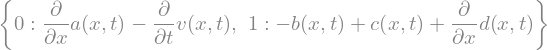

In [8]:
H_split = split_lambda(eq_H)
H_split

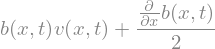

In [22]:
eq_a = solve(Ep_split[0], a)
eq_a[0]

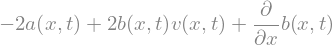

In [16]:
simplify(Ep_split[0])

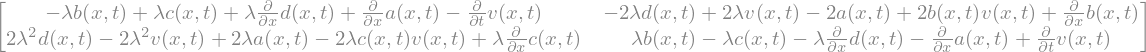

In [5]:
display(zc)
# pprint(zc)

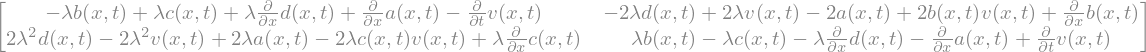

In [50]:
display(zc_old)
